# Leukemia Cell Classification (C‑NMC 2019)


In [7]:

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


In [8]:

dataset_path = "/kaggle/input/datasets/imasifahmed/c-nmc-2019-dataset/C-NMC(2019)"
classes = os.listdir(dataset_path)
print("Classes:", classes)


Classes: ['all', 'normal']


In [9]:

class_counts = {}
for c in classes:
    class_counts[c] = len(os.listdir(os.path.join(dataset_path, c)))

table1a = pd.DataFrame(list(class_counts.items()), columns=["Class","Number of Images"])
print("Table 1(a): Per Class Distribution")
display(table1a)


Table 1(a): Per Class Distribution


,Class,Number of Images
0,all,7272
1,normal,3389


In [10]:

images = []
labels = []

for c in classes:
    folder = os.path.join(dataset_path, c)
    for img in os.listdir(folder):
        images.append(os.path.join(folder, img))
        labels.append(c)

df = pd.DataFrame({"image": images, "label": labels})
print("Total Images:", len(df))
df.head()


Total Images: 10661


,image,label
0,/kaggle/input/datasets/imasifahmed/c-nmc-2019-...,all
1,/kaggle/input/datasets/imasifahmed/c-nmc-2019-...,all
2,/kaggle/input/datasets/imasifahmed/c-nmc-2019-...,all
3,/kaggle/input/datasets/imasifahmed/c-nmc-2019-...,all
4,/kaggle/input/datasets/imasifahmed/c-nmc-2019-...,all


In [11]:

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

table1b = pd.DataFrame({
    "Dataset": ["Train","Validation","Test"],
    "Images": [len(train_df), len(val_df), len(test_df)]
})

print("Table 1(b): Dataset Split Distribution")
display(table1b)


Table 1(b): Dataset Split Distribution


,Dataset,Images
0,Train,7462
1,Validation,1599
2,Test,1600


In [12]:

train_dist = train_df['label'].value_counts()
val_dist = val_df['label'].value_counts()
test_dist = test_df['label'].value_counts()

table1c = pd.concat([train_dist, val_dist, test_dist], axis=1)
table1c.columns = ["Train","Validation","Test"]

print("Table 1(c): Class Distribution per Split")
display(table1c)


Table 1(c): Class Distribution per Split


,Train,Validation,Test
label,,,
all,5090,1091,1091
normal,2372,508,509


In [13]:

img_size = (224,224)
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    train_df,
    x_col="image",
    y_col="label",
    target_size=img_size,
    class_mode="categorical",
    batch_size=batch_size
)

val_data = val_gen.flow_from_dataframe(
    val_df,
    x_col="image",
    y_col="label",
    target_size=img_size,
    class_mode="categorical",
    batch_size=batch_size
)

test_data = test_gen.flow_from_dataframe(
    test_df,
    x_col="image",
    y_col="label",
    target_size=img_size,
    class_mode="categorical",
    shuffle=False
)


Found 7462 validated image filenames belonging to 2 classes.
Found 1599 validated image filenames belonging to 2 classes.
Found 1600 validated image filenames belonging to 2 classes.


In [14]:

model = models.Sequential([
layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
layers.MaxPooling2D(2,2),

layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),

layers.Conv2D(128,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),

layers.Flatten(),
layers.Dense(128,activation='relu'),
layers.Dense(len(classes),activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1773323227.995885      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [15]:

model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:

table2 = pd.DataFrame({
"Parameter":["Loss Function","Optimizer","Learning Rate","Batch Size","Epoch"],
"Value":["Categorical Crossentropy","Adam","0.001","32","10"]
})

print("Table 2: Training Parameters")
display(table2)


Table 2: Training Parameters


,Parameter,Value
0,Loss Function,Categorical Crossentropy
1,Optimizer,Adam
2,Learning Rate,0.001
3,Batch Size,32
4,Epoch,10


In [17]:

start = time.time()

history = model.fit(
train_data,
validation_data=val_data,
epochs=10
)

training_time = time.time() - start
print("Training Time:", training_time)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1773323231.347612     123 service.cc:152] XLA service 0x78fd10006a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773323231.347646     123 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773323231.737092     123 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/234 ━━━━━━━━━━━━━━━━━━━━ 22:48 6s/step - accuracy: 0.5938 - loss: 0.6903

I0000 00:00:1773323235.635668     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


234/234 ━━━━━━━━━━━━━━━━━━━━ 64s 248ms/step - accuracy: 0.7894 - loss: 0.4908 - val_accuracy: 0.8005 - val_loss: 0.4543
Epoch 2/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - accuracy: 0.8150 - loss: 0.4408 - val_accuracy: 0.8155 - val_loss: 0.4326
Epoch 3/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.8208 - loss: 0.4156 - val_accuracy: 0.8118 - val_loss: 0.4306
Epoch 4/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.8364 - loss: 0.3773 - val_accuracy: 0.8499 - val_loss: 0.3923
Epoch 5/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.8455 - loss: 0.3597 - val_accuracy: 0.8524 - val_loss: 0.3837
Epoch 6/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.8773 - loss: 0.2966 - val_accuracy: 0.8299 - val_loss: 0.4525
Epoch 7/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.8853 - loss: 0.2727 - val_accuracy: 0.8368 - val_loss: 0.4307
Epoch 8/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.9101 - loss: 0.2228 - val_accura

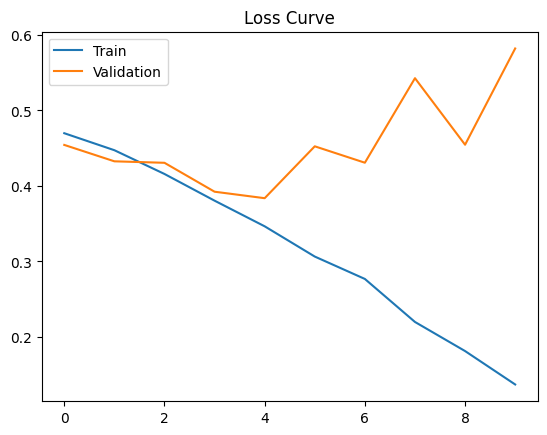

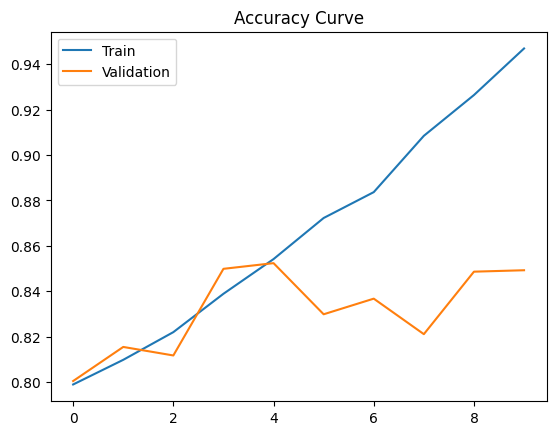

In [18]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.legend(["Train","Validation"])
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.legend(["Train","Validation"])
plt.show()


In [19]:

start = time.time()
pred = model.predict(test_data)
testing_time = time.time() - start
print("Testing Time:", testing_time)


50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 206ms/step
Testing Time: 11.10360050201416


In [20]:

y_pred = np.argmax(pred, axis=1)
y_true = test_data.classes

report = classification_report(y_true, y_pred, target_names=classes)
print("Classification Report:")
print(report)

test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_acc)


Classification Report:
              precision    recall  f1-score   support

         all       0.86      0.92      0.89      1091
      normal       0.81      0.69      0.74       509

    accuracy                           0.85      1600
   macro avg       0.83      0.81      0.82      1600
weighted avg       0.85      0.85      0.84      1600

Test Accuracy: 0.848125


In [21]:

table3 = pd.DataFrame({
"Model":["Custom CNN"],
"Training Time":[training_time],
"Testing Time":[testing_time],
"Test Accuracy":[test_acc]
})

print("Table 3: Model Result")
display(table3)


Table 3: Model Result


,Model,Training Time,Testing Time,Test Accuracy
0,Custom CNN,210.339987,11.103601,0.848125
